# 1. Environment Setup

In [29]:
# Import necessary libraries
import os
import random
import warnings
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score

PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT.name != "heart-disease-dianosis" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from app.preprocessing import (
    AddNewFeaturesTransformer,
    to_feature_dataframe,
    select_feature_columns,
)

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
print(f"Seed: {SEED}")

Seed: 42


# 2. Data Processing

## 2.1 Read CSV File Function

In [30]:
def read_csv(file_path):
    df = pd.read_csv(file_path)
    X = df.drop(columns=["target"])
    y = df["target"]
    return X, y

## 2.2 Raw Dataset

In [31]:
raw_data_dir = Path("../data/raw_dataset")
X_raw_train, y_raw_train = read_csv(raw_data_dir / "raw_train.csv")
X_raw_val, y_raw_val = read_csv(raw_data_dir / "raw_val.csv")
X_raw_test, y_raw_test = read_csv(raw_data_dir / "raw_test.csv")

## 2.3 Raw + DT Dataset

In [32]:
raw_data_dir = Path("../data/raw_dataset")
X_raw_dt_train, y_raw_dt_train = read_csv(raw_data_dir / "raw_dt_train.csv")
X_raw_dt_val, y_raw_dt_val = read_csv(raw_data_dir / "raw_dt_val.csv")
X_raw_dt_test, y_raw_dt_test = read_csv(raw_data_dir / "raw_dt_test.csv")

## 2.4 Feature Engineering Dataset

In [33]:
fe_data_dir = Path("../data/FE_dataset")
X_fe_train, y_fe_train = read_csv(fe_data_dir / "fe_train.csv")
X_fe_val, y_fe_val = read_csv(fe_data_dir / "fe_val.csv")
X_fe_test, y_fe_test = read_csv(fe_data_dir / "fe_test.csv")

## 2.5 FE + DT Dataset

In [34]:
fe_data_dir = Path("../data/FE_dataset")
X_fe_dt_train, y_fe_dt_train = read_csv(fe_data_dir / "fe_dt_train.csv")
X_fe_dt_val, y_fe_dt_val = read_csv(fe_data_dir / "fe_dt_val.csv")
X_fe_dt_test, y_fe_dt_test = read_csv(fe_data_dir / "fe_dt_test.csv")

# 3. XGBoost Model

## 3.1 Find Optimal n_estimators

In [35]:
def find_optimal_xgb(X_train, y_train, n_splits=3, n_estimators_list=range(50, 501, 50), random_state=SEED, subsample=1.0, use_gpu=False, learning_rate=0.1):
    n_estimators_list = list(n_estimators_list)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    score_list = []

    n_classes = len(np.unique(y_train))
    objective = 'binary:logistic' if n_classes == 2 else 'multi:softprob'
    eval_metric = 'logloss' if n_classes == 2 else 'mlogloss'

    for n_estimators in n_estimators_list:
        model = XGBClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=5,
            subsample=subsample,
            random_state=random_state,
            use_gpu=use_gpu,
            objective=objective, 
            eval_metric=eval_metric,
            verbosity=0
        )

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy",
            n_jobs=-1
        )
        score_list.append(scores.mean())

    best_index = int(np.argmax(score_list))
    best_n_estimators = n_estimators_list[best_index]
    print(f"The optimal n_estimators (CV): {best_n_estimators}")

    plt.figure(figsize=(10, 6))
    plt.plot(n_estimators_list, score_list, "bo-")
    plt.title(f"The optimal n_estimators for XGBoost (CV={n_splits}-fold)")
    plt.xlabel("n_estimators")
    plt.ylabel("Cross-Validation Accuracy")
    plt.grid(True)
    plt.show()

    return best_n_estimators, score_list

## 3.2 Build Training And Evaluation Class

In [36]:
class XGBoostDiagnosis:
    def __init__(self, random_state=42, n_splits=3, n_estimators_list=range(50, 501, 50)):
        self.random_state = random_state
        self.n_splits = n_splits
        self.n_estimators_list = list(n_estimators_list)
        self.model = None
        self.best_n_estimators = None
        self.cv_scores = None
        self.val_accs = []
        self.test_accs = []

    def fit(self, X_train, y_train):
        self.best_n_estimators, self.cv_scores = find_optimal_xgb(
            X_train,
            y_train,
            n_splits=self.n_splits,
            n_estimators_list=self.n_estimators_list,
            random_state=self.random_state
        )
        self.model = XGBClassifier(
            n_estimators=self.best_n_estimators,
            learning_rate=0.1,
            max_depth=5,
            subsample=1.0,
            random_state=self.random_state,
            objective='binary:logistic',
            eval_metric='logloss',
            verbosity=0
        )
        self.model.fit(X_train, y_train)
        return self

    def evaluate_val(self, X_val, y_val):
        y_pred = self.model.predict(X_val)
        acc = accuracy_score(y_val, y_pred)
        print(f"Accuracy on validation set: {acc:.4f}")
        print(f"Classification Report on validation set:\n{classification_report(y_val, y_pred)}")
        self.val_accs.append(acc)
        return acc

    def evaluate_test(self, X_test, y_test):
        y_pred = self.model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy on test set: {acc:.4f}")
        print(f"Classification Report on test set:\n{classification_report(y_test, y_pred)}")
        self.test_accs.append(acc)
        return acc

## 3.3 Train On Raw Dataset

The optimal n_estimators (CV): 300


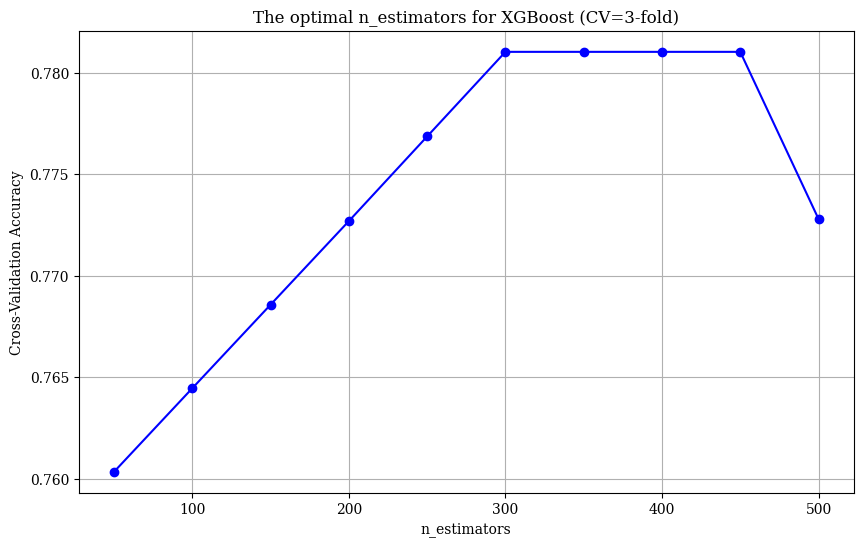

In [37]:
XGB_model = XGBoostDiagnosis(random_state=SEED, n_splits=3)
XGB_model.fit(X_raw_train, y_raw_train)

In [38]:
XGB_model.evaluate_val(X_raw_val, y_raw_val)

Accuracy on validation set: 0.9000
Classification Report on validation set:
              precision    recall  f1-score   support

           0       1.00      0.81      0.90        16
           1       0.82      1.00      0.90        14

    accuracy                           0.90        30
   macro avg       0.91      0.91      0.90        30
weighted avg       0.92      0.90      0.90        30



0.9

In [39]:
XGB_model.evaluate_test(X_raw_test, y_raw_test)

Accuracy on test set: 0.8387
Classification Report on test set:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        17
           1       0.80      0.86      0.83        14

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



0.8387096774193549

## 3.4 Train On Raw Dataset With DT Feature Selection

The optimal n_estimators (CV): 50


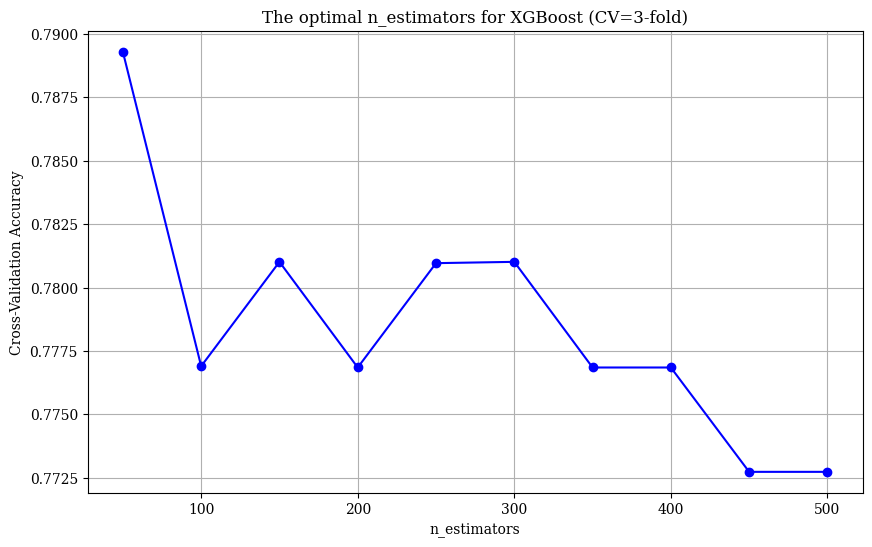

In [40]:
XGB_model.fit(X_raw_dt_train, y_raw_dt_train)

In [41]:
XGB_model.evaluate_val(X_raw_dt_val, y_raw_dt_val)

Accuracy on validation set: 0.9333
Classification Report on validation set:
              precision    recall  f1-score   support

           0       1.00      0.88      0.93        16
           1       0.88      1.00      0.93        14

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.93        30
weighted avg       0.94      0.93      0.93        30



0.9333333333333333

In [42]:
XGB_model.evaluate_test(X_raw_dt_test, y_raw_dt_test)

Accuracy on test set: 0.8065
Classification Report on test set:
              precision    recall  f1-score   support

           0       0.87      0.76      0.81        17
           1       0.75      0.86      0.80        14

    accuracy                           0.81        31
   macro avg       0.81      0.81      0.81        31
weighted avg       0.81      0.81      0.81        31



0.8064516129032258

## 3.5 Train On FE Dataset

The optimal n_estimators (CV): 400


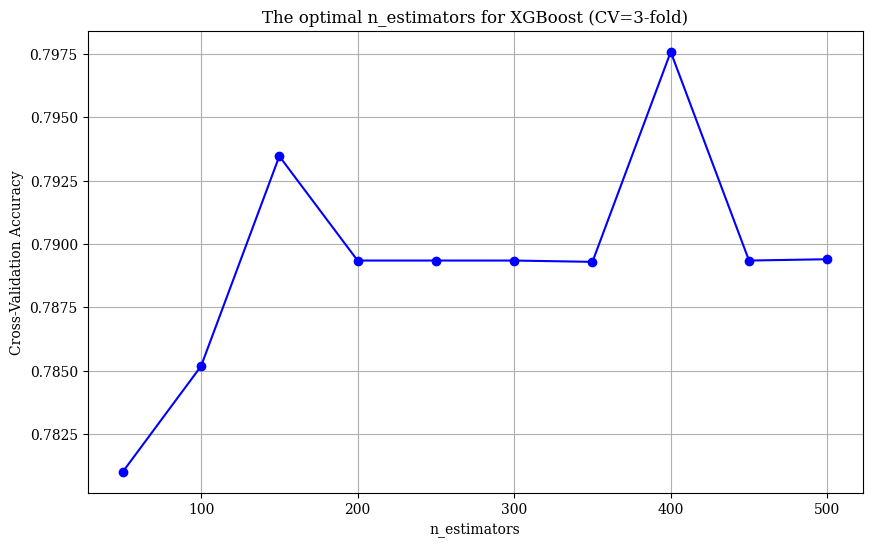

In [43]:
XGB_model.fit(X_fe_train, y_fe_train)

In [44]:
XGB_model.evaluate_val(X_fe_val, y_fe_val)

Accuracy on validation set: 0.8667
Classification Report on validation set:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87        16
           1       0.81      0.93      0.87        14

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30



0.8666666666666667

In [45]:
XGB_model.evaluate_test(X_fe_test, y_fe_test)

Accuracy on test set: 0.8387
Classification Report on test set:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86        17
           1       0.85      0.79      0.81        14

    accuracy                           0.84        31
   macro avg       0.84      0.83      0.84        31
weighted avg       0.84      0.84      0.84        31



0.8387096774193549

## 3.6 Train On FE Dataset With DT Feature Selection

The optimal n_estimators (CV): 100


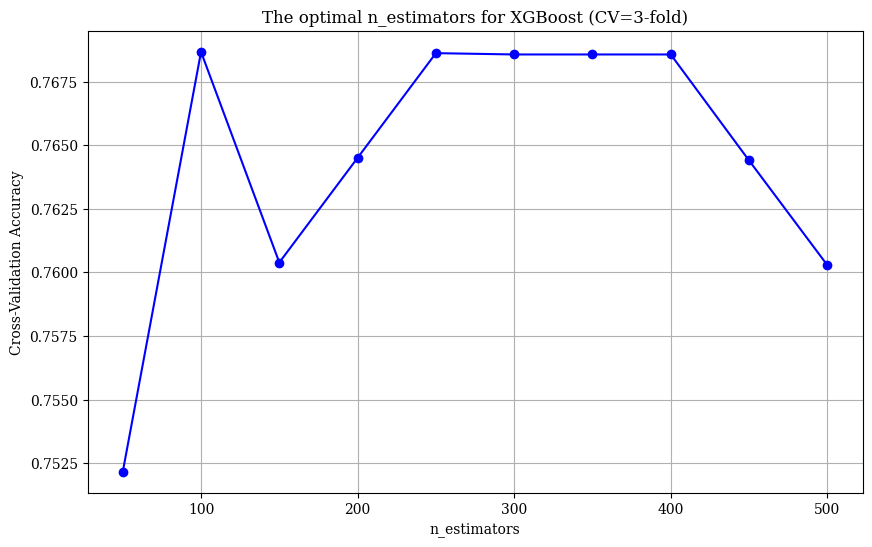

In [46]:
XGB_model.fit(X_fe_dt_train, y_fe_dt_train)

In [47]:
XGB_model.evaluate_val(X_fe_dt_val, y_fe_dt_val)

Accuracy on validation set: 0.9000
Classification Report on validation set:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90        16
           1       0.87      0.93      0.90        14

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



0.9

In [48]:
XGB_model.evaluate_test(X_fe_dt_test, y_fe_dt_test)

Accuracy on test set: 0.8710
Classification Report on test set:
              precision    recall  f1-score   support

           0       0.93      0.82      0.88        17
           1       0.81      0.93      0.87        14

    accuracy                           0.87        31
   macro avg       0.87      0.88      0.87        31
weighted avg       0.88      0.87      0.87        31



0.8709677419354839

### Saving model as artifact

In [49]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in {"models", "notebooks"}:
    PROJECT_ROOT = PROJECT_ROOT.parent

ARTIFACT_DIR = PROJECT_ROOT / "models" / "trained_models"

preprocess_artifact = joblib.load(
    ARTIFACT_DIR / "fe_dt_preprocess_pipeline.joblib"
)

In [50]:
deployment_pipeline=Pipeline(steps=[
    ("preprocess", preprocess_artifact["preprocess_pipeline"]),
    (
            "to_dataframe",
            FunctionTransformer(
                to_feature_dataframe,
                kw_args={"feature_names": preprocess_artifact["full_feature_names"]},
                validate=False,
            ),
    ),
    (
            "select_features",
            FunctionTransformer(
                select_feature_columns,
                kw_args={"selected_features": preprocess_artifact["selected_feature_names"]},
                validate=False,
            ),
        ),
    ("model", XGB_model.model),
])

In [51]:
artifact = {
    "model_name": "Gradient Boosting",
    "dataset_name": "FE_DT",
    "pipeline": deployment_pipeline,
}

joblib.dump(
    artifact,
    ARTIFACT_DIR / "xgboost_fe_dt.joblib",
)

['/Users/buithanhduy/Desktop/heart-disease-dianosis/models/trained_models/xgboost_fe_dt.joblib']

# 4. Result Visualization

In [52]:
print(XGB_model.val_accs)
print(XGB_model.test_accs)

[0.9, 0.9333333333333333, 0.8666666666666667, 0.9]
[0.8387096774193549, 0.8064516129032258, 0.8387096774193549, 0.8709677419354839]


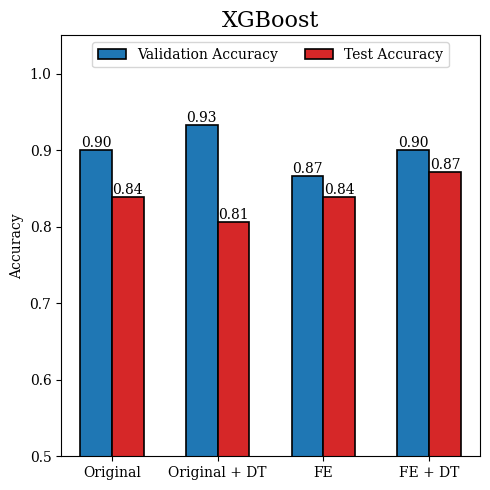

In [53]:
plt.rcParams["font.family"] = "Serif"

labels = ["Original", "Original + DT", "FE",  "FE + DT"]
val_accs = XGB_model.val_accs
test_accs = XGB_model.test_accs

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(5, 5))

rects1 = ax.bar(
    x - width / 2,
    val_accs,
    width,
    label="Validation Accuracy",
    color="tab:blue",
    edgecolor="black",
    linewidth=1.2
)
rects2 = ax.bar(
    x + width / 2,
    test_accs,
    width,
    label="Test Accuracy",
    color="tab:red",
    edgecolor="black",
    linewidth=1.2
)

ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("XGBoost", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(ncol=2, loc="upper center")

def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(
            f"{h:.2f}",
            xy=(rect.get_x() + rect.get_width() / 2, h),
            ha="center",
            va="bottom"
        )

autolabel(rects1)
autolabel(rects2)
fig.tight_layout()
plt.show()